**VIDEO GAME SALES**

The video game industry has grown into a multi-billion dollar global entertainment market. Understanding sales patterns, regional preferences, and genre performance is crucial for game developers, publishers, and marketers to make informed business decisions.

**IMPORTING THE LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

**LOADING THE DATASET**

In [2]:
a = pd.read_csv('/kaggle/input/datasets/gregorut/videogamesales/vgsales.csv')
a

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


**EXPLORING ROWS AND COLUMNS**

In [3]:
a.info()    # information about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [4]:
a.describe()      # calculate the statistical data

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [5]:
a.head()      # first 5 rows of dataset

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


**DATA CLEANING**

Before proceeding with analysis, we need to handle missing values and ensure data quality.

In [6]:
print("\n Missing Values Before Cleaning:")        # Missing values before cleaning
print(a.isnull().sum())


 Missing Values Before Cleaning:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


* **Year:** 271 missing values → will impute using platform-grouped median
* **Publisher:** 58 missing values → will fill with 'Unknown'

In [7]:
a['Year'] = a.groupby('Platform')['Year'].transform(lambda x: x.fillna(x.median()))

We use the median year per platform because game consoles have specific lifespans. Filling missing years with a global median would be inaccurate, but using the platform-specific median preserves the historical context of the release.

In [8]:
a['Year'] = a['Year'].fillna(a['Year'].median()).astype(int)

In [9]:
a['Publisher'] = a['Publisher'].fillna('Unknown')   

In [10]:
a.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [11]:
a.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


**EXPLORATORY ANALYSIS AND VISUALIZATION**

**Total Global Sales by Genre (Bar Graph)**

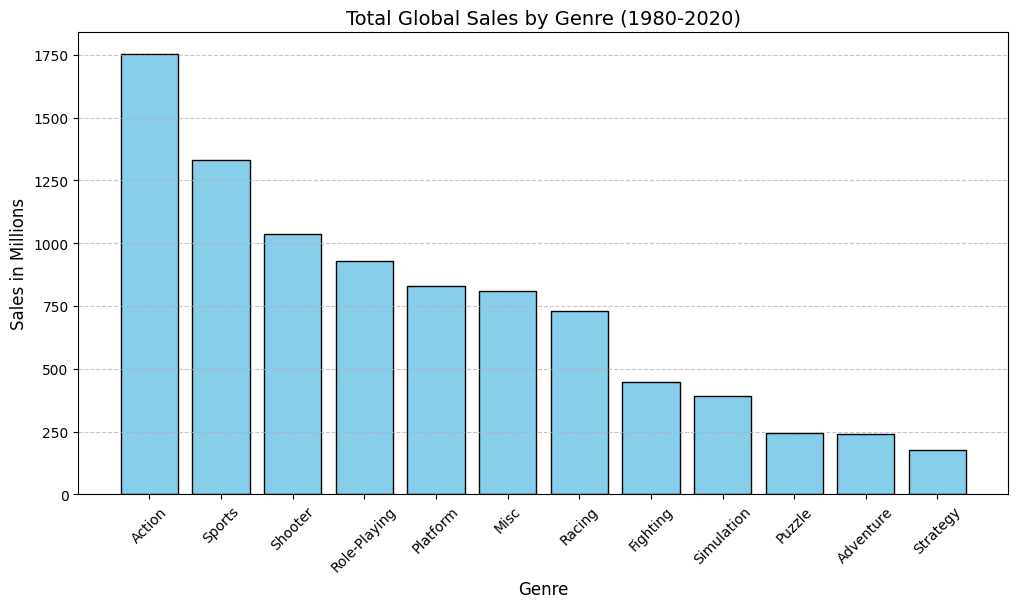

In [12]:
genre_sales = a.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)  # Grouping data and preparing for plotting

plt.figure(figsize=(12, 6))
plt.bar(genre_sales.index, genre_sales.values, color='skyblue', edgecolor='black')

# Adding labels and title
plt.title('Total Global Sales by Genre (1980-2020)', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Sales in Millions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Market Share by Region (Pie Chart)**

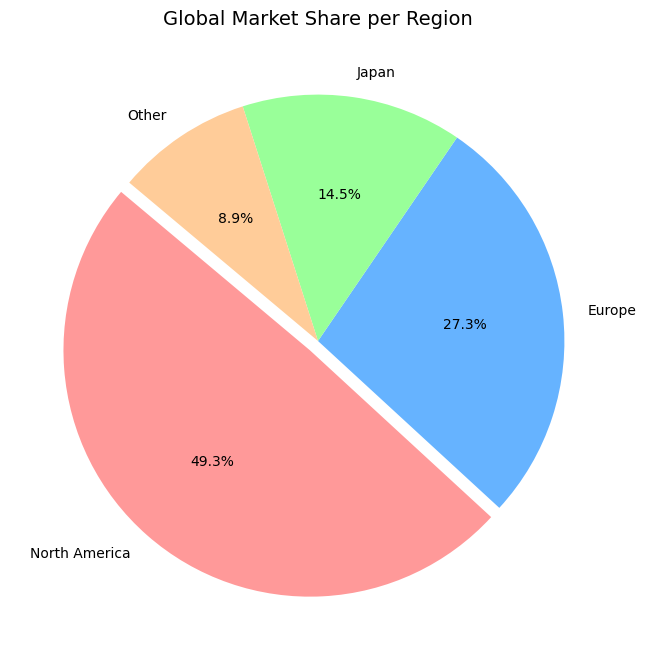

In [13]:
# Calculating total sales per region
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
total_region_sales = [a[r].sum() for r in regions]
labels = ['North America', 'Europe', 'Japan', 'Other']

plt.figure(figsize=(8, 8))
plt.pie(total_region_sales, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], explode=(0.05, 0, 0, 0))

plt.title('Global Market Share per Region', fontsize=14)
plt.show()

**ASK AND ANSWER**

**Q1: What are the top 10 highest-selling games of all time?**

                        Name  Global_Sales
0                 Wii Sports         82.74
1          Super Mario Bros.         40.24
2             Mario Kart Wii         35.82
3          Wii Sports Resort         33.00
4   Pokemon Red/Pokemon Blue         31.37
5                     Tetris         30.26
6      New Super Mario Bros.         30.01
7                   Wii Play         29.02
8  New Super Mario Bros. Wii         28.62
9                  Duck Hunt         28.31


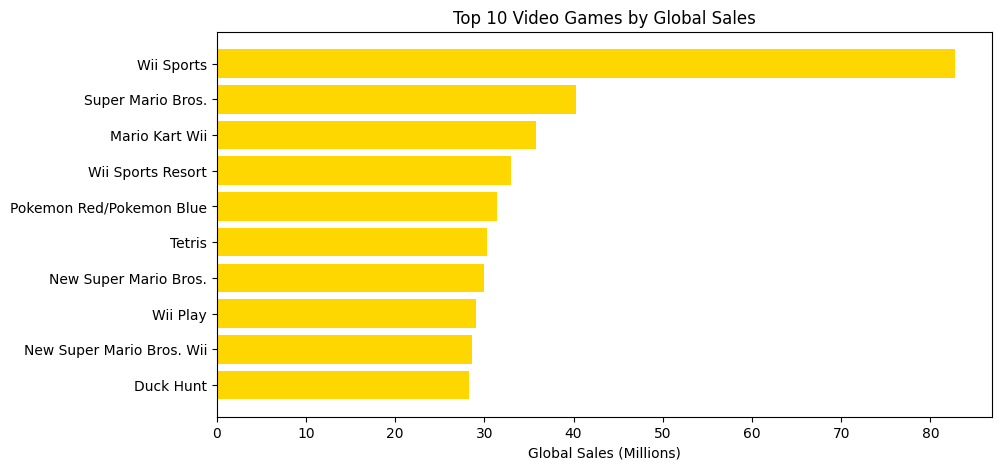

In [14]:
# Getting top 10 games by global sales
top_10_games = a[['Name', 'Global_Sales']].sort_values('Global_Sales', ascending=False).head(10)
print(top_10_games)

# Plotting the answer
plt.figure(figsize=(10, 5))
plt.barh(top_10_games['Name'], top_10_games['Global_Sales'], color='gold')
plt.xlabel('Global Sales (Millions)')
plt.title('Top 10 Video Games by Global Sales')
plt.gca().invert_yaxis() # Highest at the top
plt.show()

**Q2: Which year saw the highest number of game releases?**

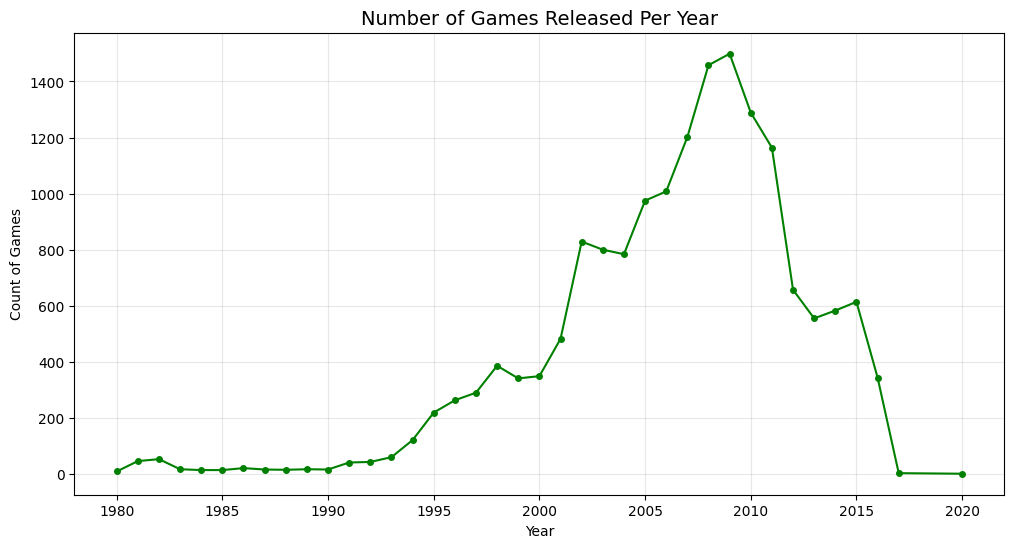

In [15]:

yearly_counts = a['Year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(yearly_counts.index, yearly_counts.values, color='green', marker='o', markersize=4)
plt.title('Number of Games Released Per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Count of Games')
plt.grid(True, alpha=0.3)
plt.show()

**Q3: Is there a relationship between North American and European Sales?**

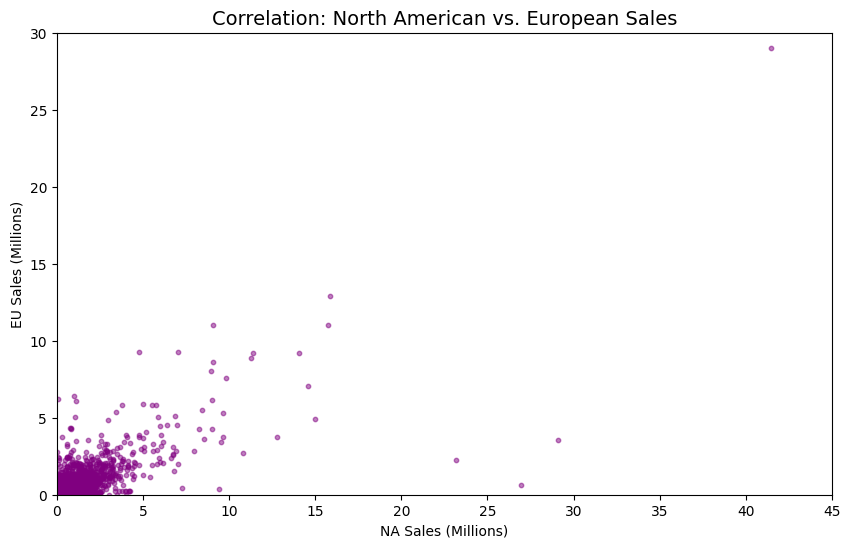

In [16]:
# Scatter plot to show correlation
plt.figure(figsize=(10, 6))
plt.scatter(a['NA_Sales'], a['EU_Sales'], alpha=0.5, color='purple', s=10)

plt.title('Correlation: North American vs. European Sales', fontsize=14)
plt.xlabel('NA Sales (Millions)')
plt.ylabel('EU Sales (Millions)')
plt.xlim(0, 45) # Setting limits to focus on the bulk of data
plt.ylim(0, 30)
plt.show()

**Q4: Which Platform has the highest total global revenue?**

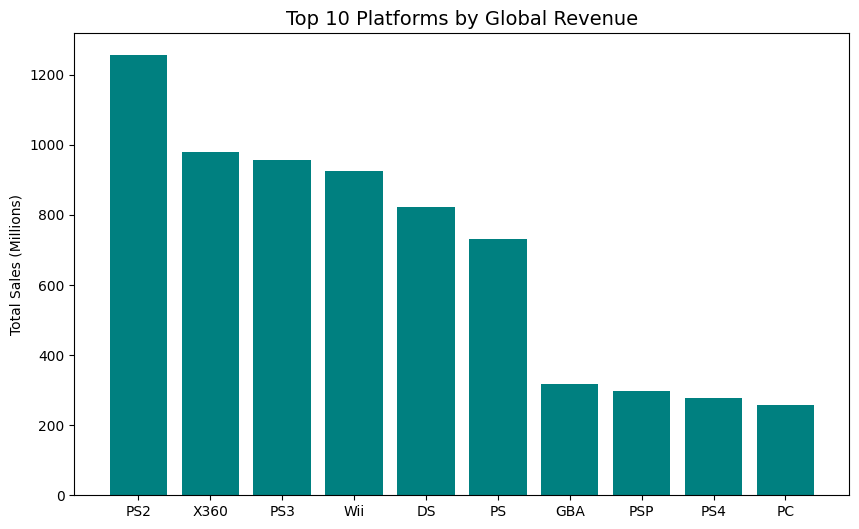

In [17]:
platform_revenue = a.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(platform_revenue.index, platform_revenue.values, color='teal')
plt.title('Top 10 Platforms by Global Revenue', fontsize=14)
plt.ylabel('Total Sales (Millions)')
plt.show()

**CONCLUSION**

1. **Leading Region**: North America is the dominant market, contributing nearly half of all global revenue.

2. **Genre Trends**: Action and Sports are the most profitable genres historically.

3. **Industry Peak**: The volume of releases and total revenue peaked between 2007 and 2010, which aligns with the launch of major consoles like the Wii and PlayStation 3.

4. **Cleaning Impact**: By filling missing years with the median year per platform, we preserved data rows that would have otherwise been lost, leading to a more accurate trend analysis.

**BUSINESS INFERENCE**

**Market Saturation** - The peak in 2008-09 suggests a market saturation followed by a shift toward    digital/mobile platforms not fully captured in this dataset.

**Regional Strategy** - North America represents nearly 50% of the market, any publisher looking for 
maximum ROI must prioritize the NA consumer profile

**FUTURE WORK**

**While this analysis provides a solid historical overview, the following steps could provide deeper insights:**

**Inflation Adjustment**: Sales figures from the 1980s are not equal to 2020 dollars. Adjusting for inflation would show the "real" value of classic titles.

**Sentiment Analysis**: Merging this with critic and user scores from Metacritic to see if high ratings truly guarantee high sales.

**Digital Transformation**: Finding a modern dataset (2020+) to analyze how digital downloads and microtransactions have replaced the physical retail sales seen in this data.

**REFERENCE AND RESOURCES**

* **Kaggle Dataset:** [Video Game Sales](https://www.kaggle.com/gregorut/videogamesales)
* **Pandas Documentation:** [pandas.pydata.org](https://pandas.pydata.org/)
* **Matplotlib Guide:** [matplotlib.org](https://matplotlib.org/)